# Reinforcement Learning for Statistical Arbitrage (v2)

Modular training pipeline with:
1. **Differential Sharpe Ratio** reward function (Moody & Saffell 1998)
2. **Fixed-length episodes** with uniform sampling across the full dataset
3. **1D-CNN feature extractor** preserving temporal structure
4. **Pair identity** in observations (one-hot encoded)
5. **Vol-dependent slippage** cost model
6. **Multi-frequency × multi-fee** experiment grid
7. **Custom Sharpe-based eval callback** for model selection
8. **VecNormalize** for observation and reward normalization

## 1 · Install & Import

In [1]:
# Uncomment once to install dependencies
# %pip -q install -U numpy pandas pyarrow gdown gymnasium stable-baselines3 torch matplotlib tensorboard tqdm psutil

In [2]:
import gc, os, sys, json, math, random, hashlib, tempfile, traceback
from datetime import datetime
from copy import deepcopy
from typing import Optional

import numpy as np
import pandas as pd
import pytz
import matplotlib.pyplot as plt
import torch
import psutil
from tqdm import tqdm
from IPython.display import display

from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv, VecNormalize
from stable_baselines3.common.monitor import Monitor

# ----- Local imports -----
from config import CONFIG, ANNUALIZATION

from src.features import (
    download_file, load_csv_to_df,
    identify_assets_features_pairs, create_feature_panel,
    resample_panel, build_time_intervals, is_timeframe_valid,
    build_all_tensors, load_tensors_from_cache, slice_by_mask,
)
from src.envs import StatArbEnv
from src.models import CNNFeatureExtractor
from src.training import (
    SharpeEvalCallback, ActionStatsCallback, PolicyCollapseCallback,
    create_model, train_single, train_multi_fee, train_multi_frequency,
)
from src.evaluation import (
    backtest_env, compute_metrics, plot_equity_curves, plot_comparison,
    annualize_factor,
)

print("All imports loaded successfully.")

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
Users of this version of Gym should be able to simply replace 'import gym' with 'import gymnasium as gym' in the vast majority of cases.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


All imports loaded successfully.


## 2 · Device & Seeds

In [3]:
# Detect best available device
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using Apple Silicon GPU (MPS).")
else:
    device = torch.device("cpu")
    print("Using CPU.")

def set_all_seeds(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_all_seeds(CONFIG["ENV"]["seed"])
print(f"Seed: {CONFIG['ENV']['seed']}")

Using Apple Silicon GPU (MPS).
Seed: 42


## 3 · Download & Load Feature Data

In [4]:
# Download features CSV from Google Drive
file_name = CONFIG["DATA"]["features"]["file_name"]
file_id   = CONFIG["DATA"]["features"]["file_id"]
cache_dir = CONFIG["DATA"]["cache_dir"]

download_file(file_name, file_id, cache_dir)

# Load into DataFrame
file_path = os.path.join(cache_dir, f"{file_name}.csv")
index_col = CONFIG["DATA"]["features"]["index"]
sep = CONFIG["DATA"]["features"].get("separator", ",")

features_df = load_csv_to_df(file_path, sep, timestamp_index_col=index_col)
print(f"Shape: {features_df.shape}")
print(f"Range: {features_df.index.min()} → {features_df.index.max()}")

Skipping download. File bin_futures_full_features already exists in cache.
     Loading dataset (ca. 10 seconds)...
     Dataset loaded.
Shape: (525600, 789)
Range: 2024-05-01 00:00:00 → 2025-04-30 23:59:00


## 4 · Identify Feature Structure & Build Panel

In [5]:
# Identify assets, features, pairs
assets, single_asset_features, pair_features, asset_pairs = identify_assets_features_pairs(
    features_df,
    CONFIG["DATA"]["asset_price_format"],
    CONFIG["DATA"]["pair_feature_format"],
)

print(f"{len(assets)} assets: {assets}")
print(f"{len(single_asset_features)} single-asset features")
print(f"{len(pair_features)} pair features")
print(f"{len(asset_pairs)} pairs: {asset_pairs}")

# Create base 1-minute feature panel
panel_1m = create_feature_panel(
    features_df, assets, single_asset_features, pair_features,
    asset_pairs, CONFIG["DATA"]["pair_feature_format"],
)
print(f"\nBase panel shape: {panel_1m.shape}")

# Free raw DataFrame
del features_df
gc.collect()

25 assets: ['AAVE', 'ADA', 'APT', 'ARB', 'ATOM', 'AVAX', 'BCH', 'BNB', 'BTC', 'DOGE', 'DOT', 'ENA', 'ETC', 'ETH', 'HBAR', 'LINK', 'LTC', 'NEAR', 'SUI', 'TON', 'TRX', 'UNI', 'WLD', 'XLM', 'XRP']
12 single-asset features
8 pair features
61 pairs: [('AAVE', 'SUI'), ('AAVE', 'TRX'), ('ADA', 'BTC'), ('ADA', 'DOGE'), ('ADA', 'HBAR'), ('ADA', 'LTC'), ('ADA', 'SUI'), ('ADA', 'XLM'), ('ADA', 'XRP'), ('APT', 'AVAX'), ('ARB', 'ATOM'), ('ARB', 'AVAX'), ('ARB', 'DOT'), ('ARB', 'ETC'), ('ARB', 'ETH'), ('ARB', 'NEAR'), ('ARB', 'WLD'), ('ATOM', 'BCH'), ('ATOM', 'DOT'), ('ATOM', 'ENA'), ('ATOM', 'ETC'), ('AVAX', 'BCH'), ('AVAX', 'DOT'), ('AVAX', 'ETC'), ('AVAX', 'UNI'), ('BCH', 'DOT'), ('BCH', 'ENA'), ('BCH', 'ETC'), ('BNB', 'LINK'), ('BTC', 'DOGE'), ('BTC', 'HBAR'), ('BTC', 'LTC'), ('BTC', 'SUI'), ('BTC', 'TRX'), ('BTC', 'XLM'), ('BTC', 'XRP'), ('DOGE', 'LINK'), ('DOGE', 'LTC'), ('DOGE', 'SUI'), ('DOGE', 'XLM'), ('DOT', 'ENA'), ('DOT', 'ETC'), ('DOT', 'ETH'), ('ENA', 'ETC'), ('ENA', 'UNI'), ('ETC', 'E

20

## 5 · Build Valid Intervals

In [6]:
window = CONFIG["ENV"]["trading_window_days"]
step   = CONFIG["ENV"]["sliding_window_step"]
pair_id_feat = CONFIG["DATA"]["features"]["pair_identifier"]
pfmt = CONFIG["DATA"]["pair_feature_format"]

def get_valid_intervals(panel, asset_pairs, window, step, pair_id_feat, pfmt):
    """Build time intervals and filter to those with complete data per pair."""
    intervals = build_time_intervals(panel, window, step, include_last_partial=False)
    valid = {}
    for pair in asset_pairs:
        vi = []
        for s, e in intervals:
            if is_timeframe_valid(panel, pair, s, e, pair_id_feat, pfmt, timestamp_col=None):
                vi.append((s, e))
        valid[pair] = vi
        print(f"Pair {pair} has {len(vi)} valid intervals out of {len(intervals)} total intervals.")
    return valid

print(f"Window={window}, Step={step}")
valid_intervals_1m = get_valid_intervals(panel_1m, asset_pairs, window, step, pair_id_feat, pfmt)
total_valid = sum(len(v) for v in valid_intervals_1m.values())
print(f"Total valid intervals: {total_valid}")

Window=1D, Step=1D
Pair ('AAVE', 'SUI') has 19 valid intervals out of 364 total intervals.
Pair ('AAVE', 'TRX') has 6 valid intervals out of 364 total intervals.
Pair ('ADA', 'BTC') has 27 valid intervals out of 364 total intervals.
Pair ('ADA', 'DOGE') has 33 valid intervals out of 364 total intervals.
Pair ('ADA', 'HBAR') has 54 valid intervals out of 364 total intervals.
Pair ('ADA', 'LTC') has 31 valid intervals out of 364 total intervals.
Pair ('ADA', 'SUI') has 22 valid intervals out of 364 total intervals.
Pair ('ADA', 'XLM') has 30 valid intervals out of 364 total intervals.
Pair ('ADA', 'XRP') has 35 valid intervals out of 364 total intervals.
Pair ('APT', 'AVAX') has 35 valid intervals out of 364 total intervals.
Pair ('ARB', 'ATOM') has 32 valid intervals out of 364 total intervals.
Pair ('ARB', 'AVAX') has 35 valid intervals out of 364 total intervals.
Pair ('ARB', 'DOT') has 39 valid intervals out of 364 total intervals.
Pair ('ARB', 'ETC') has 60 valid intervals out of 36

In [7]:
# Debug: Examine the actual data structure and beta values
print("\n=== DATA STRUCTURE DEBUG ===")
print(f"Panel shape: {panel_1m.shape}")
print(f"Panel columns (first 10):\n{panel_1m.columns[:10].tolist()}")

# Check for NaN in beta column for a few pairs
test_pairs = [("AAVE", "SUI"), ("ADA", "BTC"), ("ARB", "ATOM")]
for pair in test_pairs:
    pair_str = f"{pair[0]}_{pair[1]}"
    if isinstance(panel_1m.columns, pd.MultiIndex):
        col = (pair_str, "beta")
    else:
        col = f"{pair_str}_beta"
    
    if col in panel_1m.columns:
        beta_col = panel_1m[col]
        nan_count = beta_col.isna().sum()
        nan_pct = 100 * nan_count / len(beta_col)
        print(f"\n{pair}: beta column has {nan_count} NaN ({nan_pct:.1f}%)")
        if nan_count > 0:
            print(f"  Non-NaN range: {beta_col[beta_col.notna()].index.min()} to {beta_col[beta_col.notna()].index.max()}")
    else:
        print(f"\n{pair}: beta column NOT FOUND")
        print(f"  Available columns for {pair_str}: {[c[1] for c in panel_1m.columns if c[0] == pair_str]}")


=== DATA STRUCTURE DEBUG ===
Panel shape: (525600, 788)
Panel columns (first 10):
[('AAVE', 'close'), ('AAVE', 'closeBias'), ('AAVE', 'closeEwmaVol'), ('AAVE', 'closeKalman'), ('AAVE', 'closeLowerShadow'), ('AAVE', 'closeMacd'), ('AAVE', 'closeRsi'), ('AAVE', 'closeSigns'), ('AAVE', 'closeStochRsi'), ('AAVE', 'closeUpperShadow')]

('AAVE', 'SUI'): beta column has 498240 NaN (94.8%)
  Non-NaN range: 2024-05-20 00:00:00+00:00 to 2025-04-24 23:59:00+00:00

('ADA', 'BTC'): beta column has 486720 NaN (92.6%)
  Non-NaN range: 2024-06-16 00:00:00+00:00 to 2025-04-11 23:59:00+00:00

('ARB', 'ATOM'): beta column has 479520 NaN (91.2%)
  Non-NaN range: 2024-05-15 00:00:00+00:00 to 2025-04-28 23:59:00+00:00


## 6 · Build Tensors for Each Frequency

We build tensors at the base 1-minute frequency, then resample the panel to each
target frequency and build separate tensor sets. This ensures the full dataset is
used for training, validation, and testing at each frequency.

In [8]:
# Ensure notebook uses latest tensor_builder implementation after edits.
import importlib
import src.features.tensor_builder as tb
importlib.reload(tb)

resample_panel = tb.resample_panel
build_all_tensors = tb.build_all_tensors
load_tensors_from_cache = tb.load_tensors_from_cache

FREQUENCIES = CONFIG["ENV"]["frequency"]  # e.g. ["1m", "5m", "30m"]
LOOKBACK_DEFAULT = CONFIG["ENV"]["lookback_window"]
LOOKBACK_BY_FREQ = CONFIG["ENV"].get("lookback_window_map", {})
TENSOR_CACHE_BASE = os.path.join(CONFIG["DATA"]["cache_dir"], "tensors")

# Debug safety: set True to bypass stale cache and fully rebuild tensors.
FORCE_REBUILD_TENSORS = True

# Storage: freq -> (X_all, R_all, VOL_all, metadata)
TENSORS_BY_FREQ = {}

base_window_td = pd.Timedelta(window)
step_td = pd.Timedelta(step)

for freq in FREQUENCIES:
    lookback_freq = int(LOOKBACK_BY_FREQ.get(freq, LOOKBACK_DEFAULT))

    print(f"\n{'='*60}")
    print(f"BUILDING TENSORS @ {freq}")
    print(f"{'='*60}")
    print(f"  Lookback @ {freq}: {lookback_freq}")

    cache_dir_freq = os.path.join(TENSOR_CACHE_BASE, freq)

    # Resample panel to target frequency and (re)build valid intervals first.
    if freq == "1m":
        panel_freq = panel_1m
    else:
        print(f"  Resampling panel from 1m -> {freq}...")
        panel_freq = resample_panel(panel_1m, target_freq=freq, base_freq="1m")
        print(f"  Resampled panel shape: {panel_freq.shape}")

    # Ensure each interval is long enough to produce at least one sample for this LOOKBACK.
    if len(panel_freq.index) < 2:
        raise ValueError(f"Panel @ {freq} has insufficient rows after resampling.")
    freq_td = panel_freq.index.to_series().diff().dropna().median()
    min_window_td = freq_td * (lookback_freq + 1)
    window_td_for_freq = max(base_window_td, min_window_td)

    if window_td_for_freq > base_window_td:
        print(
            f"  Window adjusted for {freq}: {base_window_td} -> {window_td_for_freq} "
            f"(LOOKBACK={lookback_freq}, bars/window must exceed lookback)"
        )

    if freq == "1m" and window_td_for_freq == base_window_td:
        valid_freq = valid_intervals_1m
    else:
        valid_freq = get_valid_intervals(
            panel_freq,
            asset_pairs,
            str(window_td_for_freq),
            str(step_td),
            pair_id_feat,
            pfmt,
        )

    total_valid_freq = sum(len(v) for v in valid_freq.values())
    print(f"  Total valid intervals @ {freq}: {total_valid_freq}")

    # Try loading from cache only when explicitly allowed.
    cached = None
    if not FORCE_REBUILD_TENSORS:
        cached = load_tensors_from_cache(cache_dir_freq)

    if cached is not None:
        TENSORS_BY_FREQ[freq] = cached
        print(f"  Loaded from cache: X={cached[0].shape}")
    else:
        if FORCE_REBUILD_TENSORS and os.path.exists(cache_dir_freq):
            print("  FORCE_REBUILD_TENSORS=True -> overwriting existing cache")

        X, R, V, meta = build_all_tensors(
            panel_freq, valid_freq, lookback_freq,
            cache_dir=cache_dir_freq,
        )
        TENSORS_BY_FREQ[freq] = (X, R, V, meta)

    if freq != "1m":
        del panel_freq
        gc.collect()

print(f"\n{'='*60}")
print("TENSOR SUMMARY")
print(f"{'='*60}")
for freq, (X, R, V, m) in TENSORS_BY_FREQ.items():
    print(f"  {freq:>4s}: lookback={m.get('lookback', '?')}, X={X.shape}, tickers={m.get('TICKER_ORDER', '?')}")


BUILDING TENSORS @ 1m
  Lookback @ 1m: 60
  Total valid intervals @ 1m: 1774
  FORCE_REBUILD_TENSORS=True -> overwriting existing cache


Building tensors: 100%|██████████| 61/61 [00:41<00:00,  1.47pair/s]


Tensors built: X=(2449894, 1, 32, 60), R=(2449894, 2), VOL=(2449894, 1)

BUILDING TENSORS @ 5m
  Lookback @ 5m: 30
  Resampling panel from 1m -> 5m...
  Resampled panel shape: (105120, 788)
Pair ('AAVE', 'SUI') has 19 valid intervals out of 364 total intervals.
Pair ('AAVE', 'TRX') has 6 valid intervals out of 364 total intervals.
Pair ('ADA', 'BTC') has 27 valid intervals out of 364 total intervals.
Pair ('ADA', 'DOGE') has 33 valid intervals out of 364 total intervals.
Pair ('ADA', 'HBAR') has 54 valid intervals out of 364 total intervals.
Pair ('ADA', 'LTC') has 31 valid intervals out of 364 total intervals.
Pair ('ADA', 'SUI') has 22 valid intervals out of 364 total intervals.
Pair ('ADA', 'XLM') has 30 valid intervals out of 364 total intervals.
Pair ('ADA', 'XRP') has 35 valid intervals out of 364 total intervals.
Pair ('APT', 'AVAX') has 35 valid intervals out of 364 total intervals.
Pair ('ARB', 'ATOM') has 32 valid intervals out of 364 total intervals.
Pair ('ARB', 'AVAX') has

Building tensors: 100%|██████████| 61/61 [00:07<00:00,  8.07pair/s]


Tensors built: X=(459466, 1, 32, 30), R=(459466, 2), VOL=(459466, 1)

BUILDING TENSORS @ 30m
  Lookback @ 30m: 10
  Resampling panel from 1m -> 30m...
  Resampled panel shape: (17520, 788)
Pair ('AAVE', 'SUI') has 19 valid intervals out of 364 total intervals.
Pair ('AAVE', 'TRX') has 6 valid intervals out of 364 total intervals.
Pair ('ADA', 'BTC') has 27 valid intervals out of 364 total intervals.
Pair ('ADA', 'DOGE') has 33 valid intervals out of 364 total intervals.
Pair ('ADA', 'HBAR') has 54 valid intervals out of 364 total intervals.
Pair ('ADA', 'LTC') has 31 valid intervals out of 364 total intervals.
Pair ('ADA', 'SUI') has 22 valid intervals out of 364 total intervals.
Pair ('ADA', 'XLM') has 30 valid intervals out of 364 total intervals.
Pair ('ADA', 'XRP') has 35 valid intervals out of 364 total intervals.
Pair ('APT', 'AVAX') has 35 valid intervals out of 364 total intervals.
Pair ('ARB', 'ATOM') has 32 valid intervals out of 364 total intervals.
Pair ('ARB', 'AVAX') has 

Building tensors: 100%|██████████| 61/61 [00:02<00:00, 30.44pair/s]


Tensors built: X=(69186, 1, 32, 10), R=(69186, 2), VOL=(69186, 1)

TENSOR SUMMARY
    1m: lookback=60, X=(2449894, 1, 32, 60), tickers=['AAVE', 'ADA', 'APT', 'ARB', 'ATOM', 'AVAX', 'BCH', 'BNB', 'BTC', 'DOGE', 'DOT', 'ENA', 'ETC', 'ETH', 'HBAR', 'LINK', 'LTC', 'NEAR', 'SUI', 'TON', 'TRX', 'UNI', 'WLD', 'XLM', 'XRP']
    5m: lookback=30, X=(459466, 1, 32, 30), tickers=['AAVE', 'ADA', 'APT', 'ARB', 'ATOM', 'AVAX', 'BCH', 'BNB', 'BTC', 'DOGE', 'DOT', 'ENA', 'ETC', 'ETH', 'HBAR', 'LINK', 'LTC', 'NEAR', 'SUI', 'TON', 'TRX', 'UNI', 'WLD', 'XLM', 'XRP']
   30m: lookback=10, X=(69186, 1, 32, 10), tickers=['AAVE', 'ADA', 'APT', 'ARB', 'ATOM', 'AVAX', 'BCH', 'BNB', 'BTC', 'DOGE', 'DOT', 'ENA', 'ETC', 'ETH', 'HBAR', 'LINK', 'LTC', 'NEAR', 'SUI', 'TON', 'TRX', 'UNI', 'WLD', 'XLM', 'XRP']


## 7 · Define Train / Val / Test Splits

We split by date so that the **entire dataset** is used. A lookback-sized gap
between splits prevents data leakage from overlapping windows.

In [9]:
def date_slice_mask(times: pd.DatetimeIndex, start: str, end: str):
    """Boolean mask for a date range (UTC-aware)."""
    s = pd.Timestamp(start).tz_localize("UTC")
    e = pd.Timestamp(end).tz_localize("UTC")
    if times.tz is None:
        times = times.tz_localize("UTC")
    elif times.tz != pytz.UTC:
        times = times.tz_convert("UTC")
    mask = (times >= s) & (times <= e)
    if not mask.any():
        raise ValueError(f"No data in [{start}, {end}]")
    return mask

# Use the base 1-minute panel's index for mask creation
TIME_INDEX = panel_1m.index

train_mask = date_slice_mask(TIME_INDEX, CONFIG["SPLITS"]["train"][0], CONFIG["SPLITS"]["train"][1])
val_mask   = date_slice_mask(TIME_INDEX, CONFIG["SPLITS"]["val"][0],   CONFIG["SPLITS"]["val"][1])
test_mask  = date_slice_mask(TIME_INDEX, CONFIG["SPLITS"]["test"][0],  CONFIG["SPLITS"]["test"][1])

for name, m in [("Train", train_mask), ("Val", val_mask), ("Test", test_mask)]:
    t = TIME_INDEX[m]
    print(f"{name:5s}: {m.sum():>8,} steps  |  {t.min().date()} → {t.max().date()}")

SPLITS = [{
    "name": f"{CONFIG['SPLITS']['data_start']} to {CONFIG['SPLITS']['data_end']}",
    "train": train_mask, "val": val_mask, "test": test_mask,
}]

Train:  352,800 steps  |  2024-05-01 → 2024-12-31
Val  :   84,960 steps  |  2025-01-01 → 2025-02-28
Test :   87,840 steps  |  2025-03-01 → 2025-04-30


## 8 · Slice Data for Each Frequency & Split

In [10]:
# Build data_by_freq: freq -> (X_train, R_train, V_train, X_val, R_val, V_val)

data_by_freq = {}   # for training
test_by_freq = {}   # for evaluation
LOOKBACK_BY_FREQ_USED = {}  # freq -> lookback used to build tensors

split = SPLITS[0]

for freq, (X_all, R_all, V_all, meta) in TENSORS_BY_FREQ.items():
    ts = pd.DatetimeIndex(meta["SAMPLE_TIMESTAMPS"])
    print(f"\n--- {freq} ---")

    X_tr, R_tr, V_tr = slice_by_mask(X_all, R_all, V_all, ts, split["train"], TIME_INDEX)
    X_va, R_va, V_va = slice_by_mask(X_all, R_all, V_all, ts, split["val"],   TIME_INDEX)
    X_te, R_te, V_te = slice_by_mask(X_all, R_all, V_all, ts, split["test"],  TIME_INDEX)

    data_by_freq[freq] = (X_tr, R_tr, V_tr, X_va, R_va, V_va)
    test_by_freq[freq] = (X_te, R_te, V_te)
    LOOKBACK_BY_FREQ_USED[freq] = int(meta.get("lookback", CONFIG["ENV"]["lookback_window"]))

    print(f"  Lookback: {LOOKBACK_BY_FREQ_USED[freq]}")
    print(f"  Train: {X_tr.shape[0]:>8,}  Val: {X_va.shape[0]:>8,}  Test: {X_te.shape[0]:>8,}")

# Common metadata
_, _, _, meta_ref = TENSORS_BY_FREQ[FREQUENCIES[0]]
TICKER_ORDER = meta_ref["TICKER_ORDER"]


--- 1m ---
Slicing: 1644766 samples in [2024-05-01 00:00:00+00:00, 2024-12-31 23:59:00+00:00]
Slicing: 399109 samples in [2025-01-01 00:00:00+00:00, 2025-02-28 23:59:00+00:00]
Slicing: 406019 samples in [2025-03-01 00:00:00+00:00, 2025-04-30 23:59:00+00:00]
  Lookback: 60
  Train: 1,644,766  Val:  399,109  Test:  406,019

--- 5m ---
Slicing: 308464 samples in [2024-05-01 00:00:00+00:00, 2024-12-31 23:59:00+00:00]
Slicing: 74851 samples in [2025-01-01 00:00:00+00:00, 2025-02-28 23:59:00+00:00]
Slicing: 76151 samples in [2025-03-01 00:00:00+00:00, 2025-04-30 23:59:00+00:00]
  Lookback: 30
  Train:  308,464  Val:   74,851  Test:   76,151

--- 30m ---
Slicing: 46444 samples in [2024-05-01 00:00:00+00:00, 2024-12-31 23:59:00+00:00]
Slicing: 11271 samples in [2025-01-01 00:00:00+00:00, 2025-02-28 23:59:00+00:00]
Slicing: 11471 samples in [2025-03-01 00:00:00+00:00, 2025-04-30 23:59:00+00:00]
  Lookback: 10
  Train:   46,444  Val:   11,271  Test:   11,471


## 9 · Data Quality Check

In [11]:
has_issues = False
for freq, (X_tr, R_tr, V_tr, X_va, R_va, V_va) in data_by_freq.items():
    for name, arr in [("X_train", X_tr), ("R_train", R_tr), ("V_train", V_tr),
                       ("X_val", X_va), ("R_val", R_va), ("V_val", V_va)]:
        nans = np.isnan(arr).sum()
        infs = np.isinf(arr).sum()
        if nans > 0 or infs > 0:
            print(f"  [{freq}] {name}: {nans} NaN, {infs} Inf")
            has_issues = True

if has_issues:
    print("\n⚠️  Data quality issues found! Consider cleaning.")
else:
    print("Data quality check passed for all frequencies.")

  [1m] X_train: 1140027 NaN, 0 Inf
  [1m] X_val: 276633 NaN, 0 Inf
  [5m] X_train: 35730 NaN, 0 Inf
  [5m] X_val: 8670 NaN, 0 Inf

⚠️  Data quality issues found! Consider cleaning.


## 10 · Quick Environment Sanity Check

Test the new `StatArbEnv` with:
- Differential Sharpe reward
- Fixed-length episodes
- Pair identity in obs
- Vol-dependent slippage

In [12]:
# Sanity check with first frequency
freq0 = FREQUENCIES[0]
lookback0 = LOOKBACK_BY_FREQ_USED.get(freq0, CONFIG["ENV"]["lookback_window"])
X_tr, R_tr, V_tr, X_va, R_va, V_va = data_by_freq[freq0]

test_env = StatArbEnv(
    X_tr[:5000], R_tr[:5000], V_tr[:5000],
    tickers=TICKER_ORDER,
    lookback=lookback0,
    cfg_env=CONFIG["ENV"],
    frequency=freq0,
)

obs, info = test_env.reset(seed=42)

print(f"Observation shape: {obs.shape}")
print(f"  Market features: {test_env.n_features * lookback0}")
print("  Position:        3")
print(f"  Pair identity:   {test_env.n_pairs}")
print(f"  Total:           {obs.shape[0]}")
print(f"\nLookback: {lookback0}")
print(f"Episode length: {test_env.episode_length} steps")
print(f"Reward type: {test_env.reward_type}")

# Run a few steps
rewards = []
for _ in range(100):
    action = test_env.action_space.sample()
    obs, reward, done, truncated, info = test_env.step(action)
    rewards.append(reward)
    if done:
        break

print("\n100-step test:")
print(f"  Reward mean: {np.mean(rewards):.6f}")
print(f"  Reward std:  {np.std(rewards):.6f}")
print(f"  Portfolio:   {info['portfolio_value']:.6f}")
print(f"  Slippage:    {info['slippage_effective']*1e4:.2f} bps")

del test_env

Observation shape: (1924,)
  Market features: 1920
  Position:        3
  Pair identity:   1
  Total:           1924

Lookback: 60
Episode length: 10080 steps
Reward type: sharpe

100-step test:
  Reward mean: -0.233453
  Reward std:  1.347034
  Portfolio:   0.995271
  Slippage:    0.60 bps


## 11 · Multi-Frequency × Multi-Fee Training

This cell trains one model for every `(frequency, fee)` combination defined in `config.py`.

Each model uses:
- **CNN feature extractor** (temporal structure preserved)
- **Differential Sharpe reward**
- **VecNormalize** for observation & reward normalization
- **SharpeEvalCallback** to save the best model by validation Sharpe

In [13]:
import importlib
import src.training.train as train_mod
importlib.reload(train_mod)

# Rebind updated training entry points.
train_multi_fee = train_mod.train_multi_fee

FEE_STRUCTURES = CONFIG["ENV"]["transaction_costs"].get("maker_fee_structures", [0.0, 1.7, 5.0])
MODELS_DIR = CONFIG["IO"]["models_dir"]

# Use a training-specific copy to avoid mutating global CONFIG.
# gSDE can become numerically unstable on this setup (NaN policy params),
# so disable it for robust training.
cfg_train = deepcopy(CONFIG)
cfg_train["RL"]["use_sde"] = False

print(f"Frequencies:     {FREQUENCIES}")
print(f"Fee structures:  {FEE_STRUCTURES}")
print(f"Total models:    {len(FREQUENCIES) * len(FEE_STRUCTURES)}")
print(f"Timesteps/model: {int(cfg_train['RL']['timesteps']):,}")
print(f"Models dir:      {MODELS_DIR}")
print(f"use_sde:         {cfg_train['RL']['use_sde']} (forced for stability)")

all_trained_paths = {}
for freq in FREQUENCIES:
    if freq not in data_by_freq:
        print(f"No data for {freq}, skipping.")
        continue

    lookback_freq = int(LOOKBACK_BY_FREQ_USED.get(freq, CONFIG["ENV"]["lookback_window"]))
    X_tr, R_tr, V_tr, X_va, R_va, V_va = data_by_freq[freq]
    freq_dir = os.path.join(MODELS_DIR, f"freq_{freq}")

    print(f"\nTraining frequency={freq} with lookback={lookback_freq}")
    all_trained_paths[freq] = train_multi_fee(
        fee_structures=FEE_STRUCTURES,
        X_train=X_tr,
        R_train=R_tr,
        VOL_train=V_tr,
        X_val=X_va,
        R_val=R_va,
        VOL_val=V_va,
        tickers=TICKER_ORDER,
        lookback=lookback_freq,
        cfg=cfg_train,
        frequency=freq,
        models_dir=freq_dir,
        verbose=False,
    )

print("Training grid completed.")

Frequencies:     ['1m', '5m', '30m']
Fee structures:  [0.0, 1.7, 5]
Total models:    9
Timesteps/model: 200,000
Models dir:      ./models
use_sde:         False (forced for stability)

Training frequency=1m with lookback=60

ACTION STATS @ 14,400: mean=-0.1426 std=0.8831 [-1.0000, 1.0000]

ACTION STATS @ 28,800: mean=-0.3671 std=0.8399 [-1.0000, 1.0000]

ACTION STATS @ 43,200: mean=-0.6493 std=0.7474 [-1.0000, 1.0000]

ACTION STATS @ 57,600: mean=-0.9966 std=0.0385 [-1.0000, -0.3656]
  ⚠️  Low diversity

⚠️  POLICY COLLAPSE @ step 57,600  mean=-1.0000 std=0.0000

ACTION STATS @ 14,400: mean=0.2304 std=0.7442 [-1.0000, 1.0000]

ACTION STATS @ 28,800: mean=0.6903 std=0.7230 [-1.0000, 1.0000]

⚠️  POLICY COLLAPSE @ step 28,800  mean=1.0000 std=0.0000

ACTION STATS @ 14,400: mean=-0.1433 std=0.8443 [-1.0000, 1.0000]

ACTION STATS @ 28,800: mean=0.1134 std=0.9886 [-1.0000, 1.0000]

ACTION STATS @ 43,200: mean=-0.9881 std=0.0941 [-1.0000, -0.0125]

⚠️  POLICY COLLAPSE @ step 43,200  mean=-1.

In [14]:
# Smoke test: single run to verify training stability before full grid.
import importlib
import src.envs.stat_arb_env as env_mod
import src.training.train as train_mod
importlib.reload(env_mod)
importlib.reload(train_mod)

# Rebind updated symbols from reloaded modules.
StatArbEnv = env_mod.StatArbEnv
train_single = train_mod.train_single

cfg_smoke = deepcopy(CONFIG)
cfg_smoke["RL"]["use_sde"] = False
cfg_smoke["RL"]["timesteps"] = 1024

freq_smoke = FREQUENCIES[0]
fee_smoke = FEE_STRUCTURES[0]
lookback_smoke = int(LOOKBACK_BY_FREQ_USED.get(freq_smoke, CONFIG["ENV"]["lookback_window"]))

X_tr, R_tr, V_tr, X_va, R_va, V_va = data_by_freq[freq_smoke]

# Quick observation sanity check from reloaded env class.
env_smoke = StatArbEnv(
    X_tr[:5000], R_tr[:5000], V_tr[:5000],
    TICKER_ORDER, lookback_smoke, cfg_smoke["ENV"], frequency=freq_smoke
)
obs_smoke, _ = env_smoke.reset(seed=42)
print(f"obs finite after reload: {np.isfinite(obs_smoke).all()}")

_ = train_single(
    X_train=X_tr,
    R_train=R_tr,
    VOL_train=V_tr,
    X_val=X_va,
    R_val=R_va,
    VOL_val=V_va,
    tickers=TICKER_ORDER,
    lookback=lookback_smoke,
    cfg=cfg_smoke,
    frequency=freq_smoke,
    fee_bps=fee_smoke,
    models_dir=os.path.join(MODELS_DIR, "smoke_test"),
    tag=f"smoke_{freq_smoke}_{fee_smoke}bps",
    verbose=False,
)

print("Smoke test completed without NaN crash.")

obs finite after reload: True
Smoke test completed without NaN crash.


In [15]:
# Diagnostic: inspect finite-ness and scale before training
freq_diag = FREQUENCIES[0]
lookback_diag = int(LOOKBACK_BY_FREQ_USED.get(freq_diag, CONFIG["ENV"]["lookback_window"]))
X_tr, R_tr, V_tr, X_va, R_va, V_va = data_by_freq[freq_diag]

def arr_stats(name, arr):
    finite = np.isfinite(arr)
    print(f"{name}: shape={arr.shape}, finite={finite.mean()*100:.4f}%")
    print(f"  min={np.nanmin(arr):.6g}, max={np.nanmax(arr):.6g}, mean={np.nanmean(arr):.6g}, std={np.nanstd(arr):.6g}")

arr_stats("X_tr", X_tr)
arr_stats("R_tr", R_tr)
arr_stats("V_tr", V_tr)

# Inspect one environment reset observation
cfg_dbg = deepcopy(CONFIG)
cfg_dbg["RL"]["use_sde"] = False
env_dbg = StatArbEnv(
    X_tr[:5000], R_tr[:5000], V_tr[:5000],
    TICKER_ORDER, lookback_diag, cfg_dbg["ENV"], frequency=freq_diag
)
obs_dbg, _ = env_dbg.reset(seed=42)
print(f"lookback used: {lookback_diag}")
print(f"obs finite: {np.isfinite(obs_dbg).all()}, min={np.min(obs_dbg):.6g}, max={np.max(obs_dbg):.6g}")
print(f"obs nan count: {np.isnan(obs_dbg).sum()}, inf count: {np.isinf(obs_dbg).sum()}")

X_tr: shape=(1644766, 1, 32, 60), finite=99.9639%
  min=-28.7972, max=8539.5, mean=18.3614, std=67.3536
R_tr: shape=(1644766, 2), finite=100.0000%
  min=-0.0942542, max=0.0628137, mean=1.22419e-06, std=0.00134593
V_tr: shape=(1644766, 1), finite=100.0000%
  min=2.37978e-06, max=28.7972, mean=2.24244, std=2.23635
lookback used: 60
obs finite: True, min=-1.30581, max=480
obs nan count: 0, inf count: 0


## 12 · Evaluate All Models on Test Set

In [16]:
all_eval_results = []

for freq in FREQUENCIES:
    X_te, R_te, V_te = test_by_freq[freq]
    lookback_freq = int(LOOKBACK_BY_FREQ_USED.get(freq, CONFIG["ENV"]["lookback_window"]))
    ann = annualize_factor(freq)

    for fee_bps in FEE_STRUCTURES:
        tag = f"freq{freq}_fee{fee_bps}bps"
        model_dir = os.path.join(MODELS_DIR, f"freq_{freq}", tag)
        best_path = os.path.join(model_dir, "best_sharpe_model.zip")
        final_path = os.path.join(model_dir, f"{tag}_final.zip")

        mp = best_path if os.path.exists(best_path) else final_path
        if not os.path.exists(mp):
            print(f"  ⚠️  {tag}: no model found, skipping")
            continue

        print(f"\nEvaluating {tag} (lookback={lookback_freq})...")
        model = PPO.load(mp)

        # Create test env with matching fee
        cfg_env = deepcopy(CONFIG["ENV"])
        cfg_env["transaction_costs"]["taker_bps"] = fee_bps

        env = StatArbEnv(X_te, R_te, V_te, TICKER_ORDER, lookback_freq, cfg_env, frequency=freq)
        env = Monitor(env)

        ec, to, lev, act = backtest_env(env, model=model, include_leverage=True)
        metrics = compute_metrics(ec, freq, to)

        result = {
            "model_name": tag,
            "frequency": freq,
            "fee_bps": fee_bps,
            "lookback": lookback_freq,
            "equity_curve": ec,
            "actions": act,
            **metrics,
        }
        all_eval_results.append(result)
        print(f"  Sharpe={metrics['Sharpe']:.3f}  CAGR={metrics['CAGR']:.4f}  MaxDD={metrics['MaxDrawdown']:.4f}")

        del model
        gc.collect()

print(f"\nEvaluated {len(all_eval_results)} models.")


Evaluating freq1m_fee0.0bps (lookback=60)...
  Sharpe=-6.326  CAGR=-0.2967  MaxDD=-0.0123

Evaluating freq1m_fee1.7bps (lookback=60)...
  Sharpe=-15.687  CAGR=-0.8953  MaxDD=-0.0470

Evaluating freq1m_fee5bps (lookback=60)...
  Sharpe=1.034  CAGR=0.1035  MaxDD=-0.0173

Evaluating freq5m_fee0.0bps (lookback=30)...
  Sharpe=4.966  CAGR=2.1203  MaxDD=-0.0235

Evaluating freq5m_fee1.7bps (lookback=30)...
  Sharpe=4.966  CAGR=2.1203  MaxDD=-0.0235

Evaluating freq5m_fee5bps (lookback=30)...
  Sharpe=-4.730  CAGR=-0.6795  MaxDD=-0.0535

Evaluating freq30m_fee0.0bps (lookback=10)...
  Sharpe=-5.367  CAGR=-0.6754  MaxDD=-0.0454

Evaluating freq30m_fee1.7bps (lookback=10)...
  Sharpe=-6.926  CAGR=-0.7254  MaxDD=-0.0426

Evaluating freq30m_fee5bps (lookback=10)...
  Sharpe=5.567  CAGR=2.0806  MaxDD=-0.0365

Evaluated 9 models.


## 13 · Baselines (Cash / Equal Weight)

In [17]:
baseline_results = {}

for freq in FREQUENCIES:
    X_te, R_te, V_te = test_by_freq[freq]
    lookback_freq = int(LOOKBACK_BY_FREQ_USED.get(freq, CONFIG["ENV"]["lookback_window"]))
    cfg_base = deepcopy(CONFIG["ENV"])
    cfg_base["transaction_costs"]["taker_bps"] = 0.0

    # Cash baseline (action=0)
    env0 = StatArbEnv(X_te, R_te, V_te, TICKER_ORDER, lookback_freq, cfg_base, frequency=freq)
    env0 = Monitor(env0)
    ec0, to0 = backtest_env(env0, model=None)
    m0 = compute_metrics(ec0, freq, to0)

    baseline_results[freq] = {
        "model_name": f"Cash ({freq})",
        "frequency": freq,
        "lookback": lookback_freq,
        "fee_bps": 0.0,
        "equity_curve": ec0,
        **m0,
    }
    print(f"[{freq}] Cash baseline: Sharpe={m0['Sharpe']:.3f}  FinalV={ec0.iloc[-1]:.4f}")

[1m] Cash baseline: Sharpe=0.000  FinalV=1.0000
[5m] Cash baseline: Sharpe=0.000  FinalV=1.0000
[30m] Cash baseline: Sharpe=0.000  FinalV=1.0000


## 14 · Results Comparison Table

In [18]:
rows = []
for r in all_eval_results:
    rows.append({
        "Model": r["model_name"],
        "Freq": r["frequency"],
        "Fee (bps)": r["fee_bps"],
        "CAGR": r["CAGR"],
        "Sharpe": r["Sharpe"],
        "Sortino": r["Sortino"],
        "MaxDD": r["MaxDrawdown"],
        "Calmar": r["Calmar"],
        "Vol": r["Volatility"],
        "HitRatio": r["HitRatio"],
        "Turnover": r["Turnover"],
    })

# Add baselines
for freq, bl in baseline_results.items():
    rows.append({
        "Model": bl["model_name"],
        "Freq": freq,
        "Fee (bps)": 0.0,
        "CAGR": bl["CAGR"],
        "Sharpe": bl["Sharpe"],
        "Sortino": bl["Sortino"],
        "MaxDD": bl["MaxDrawdown"],
        "Calmar": bl["Calmar"],
        "Vol": bl["Volatility"],
        "HitRatio": bl["HitRatio"],
        "Turnover": bl["Turnover"],
    })

df_comparison = pd.DataFrame(rows)

# Style display
fmt = {c: "{:.4f}" for c in df_comparison.columns if c not in ("Model", "Freq", "Fee (bps)")}
fmt["Fee (bps)"] = "{:.2f}"
display(df_comparison.style.format(fmt).background_gradient(
    subset=["Sharpe", "CAGR"], cmap="RdYlGn"
))

,Model,Freq,Fee (bps),CAGR,Sharpe,Sortino,MaxDD,Calmar,Vol,HitRatio,Turnover
0,freq1m_fee0.0bps,1m,0.00,-0.2967,-6.3256,-8.3524,-0.0123,-28.5528,0.0554,0.4916,0.0057
1,freq1m_fee1.7bps,1m,1.70,-0.8953,-15.6874,-20.3307,-0.0470,-47.7956,0.1432,0.4915,0.0031
2,freq1m_fee5bps,1m,5.00,0.1035,1.0338,1.4413,-0.0173,5.9956,0.1002,0.4944,0.0028
3,freq5m_fee0.0bps,5m,0.00,2.1203,4.9659,6.6551,-0.0235,49.6906,0.2348,0.4983,0.0005
4,freq5m_fee1.7bps,5m,1.70,2.1203,4.9659,6.6551,-0.0235,49.6906,0.2348,0.4983,0.0005
5,freq5m_fee5bps,5m,5.00,-0.6795,-4.7304,-6.5019,-0.0535,-20.7624,0.2348,0.5017,0.0005
6,freq30m_fee0.0bps,30m,0.00,-0.6754,-5.3674,-7.1369,-0.0454,-24.3718,0.2063,0.4627,0.0030
7,freq30m_fee1.7bps,30m,1.70,-0.7254,-6.9261,-9.1303,-0.0426,-30.0078,0.1847,0.4478,0.0712
8,freq30m_fee5bps,30m,5.00,2.0806,5.5668,8.9888,-0.0365,31.5195,0.2065,0.5373,0.0030
9,Cash (1m),1m,0.00,0.0000,0.0000,nan,0.0000,0.0000,0.0000,0.0000,0.0000


## 15 · Visualizations


--- 1m ---


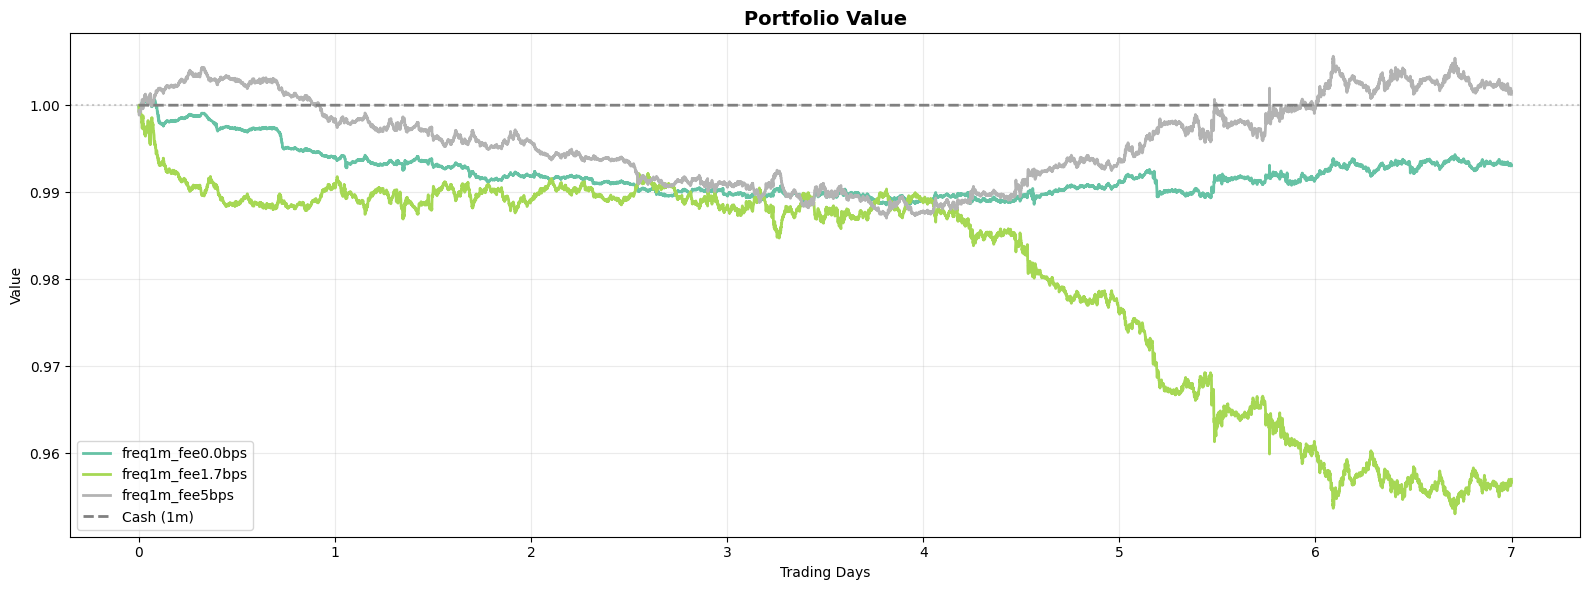

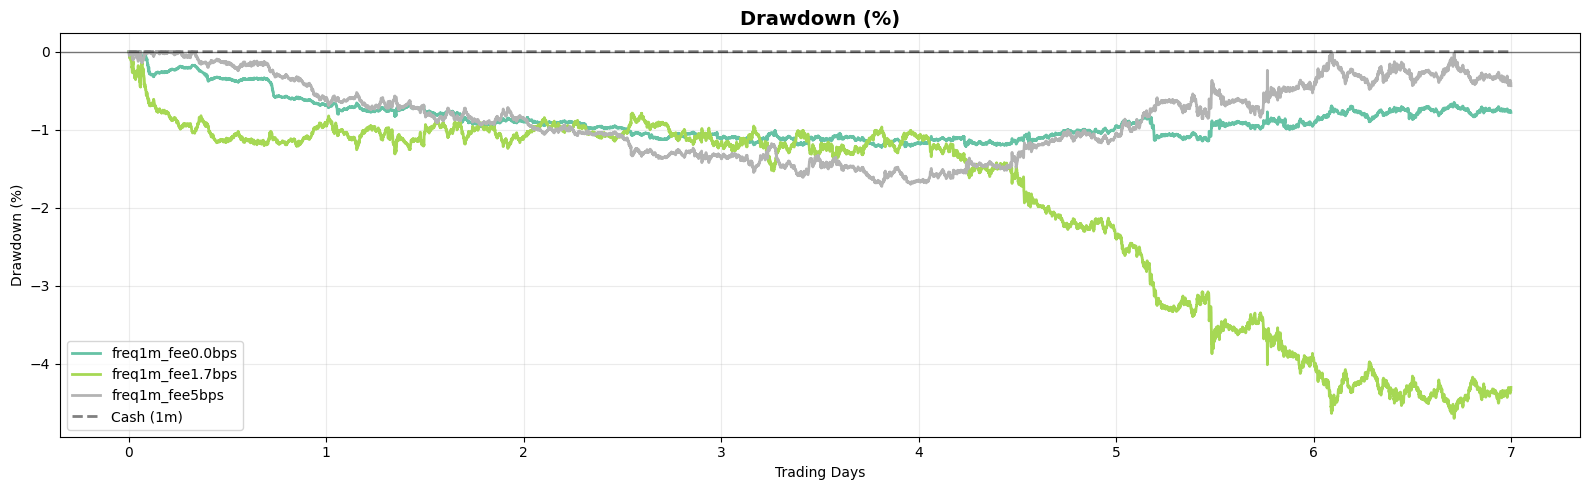

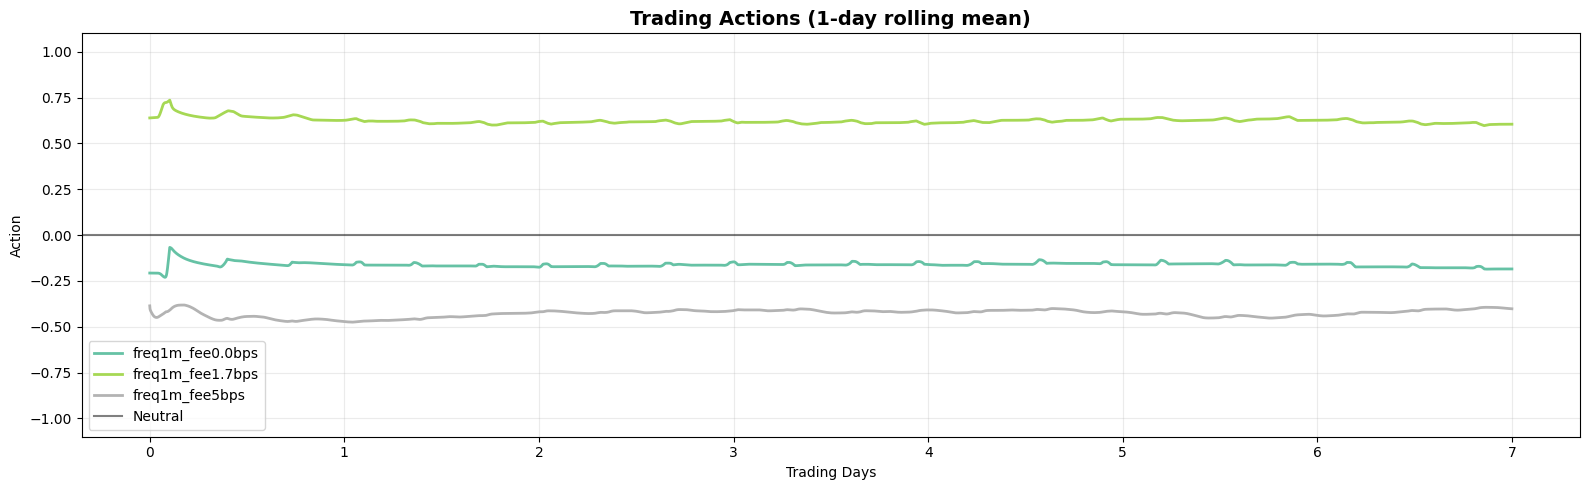


--- 5m ---


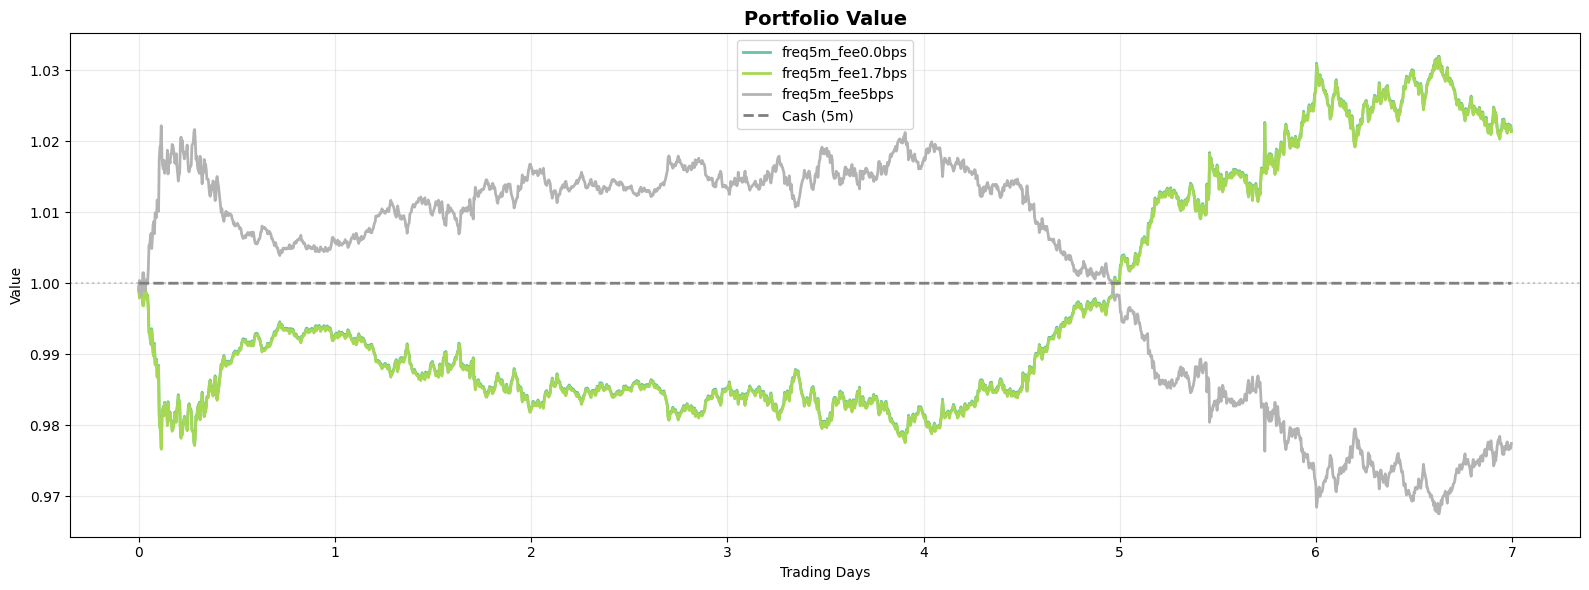

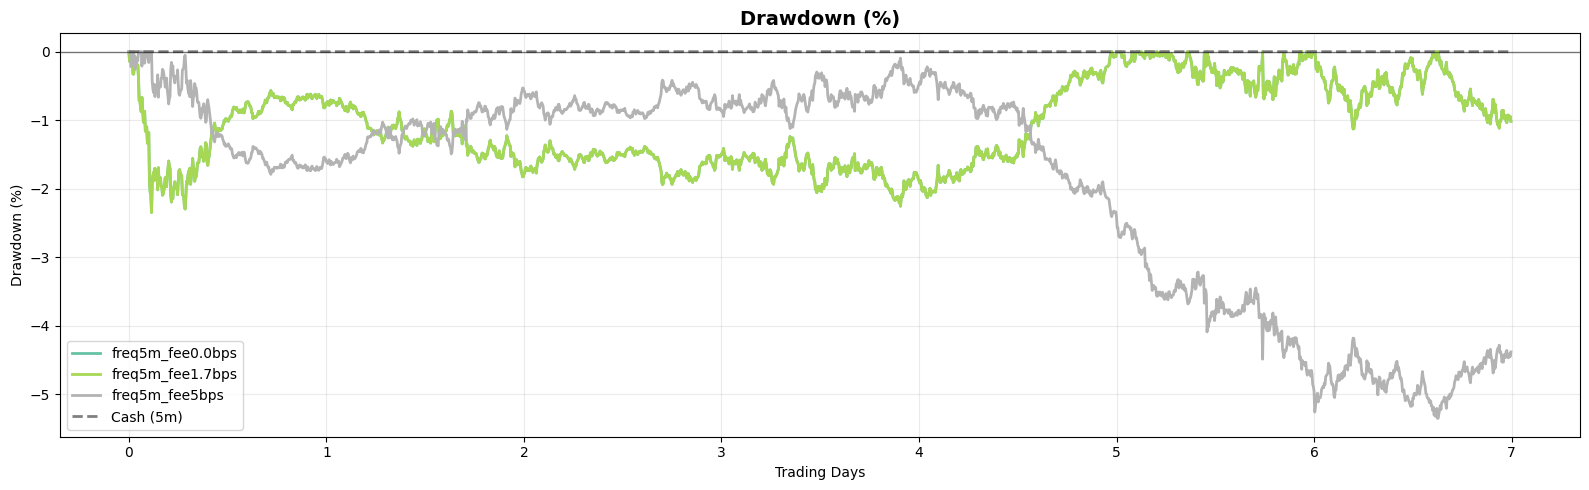

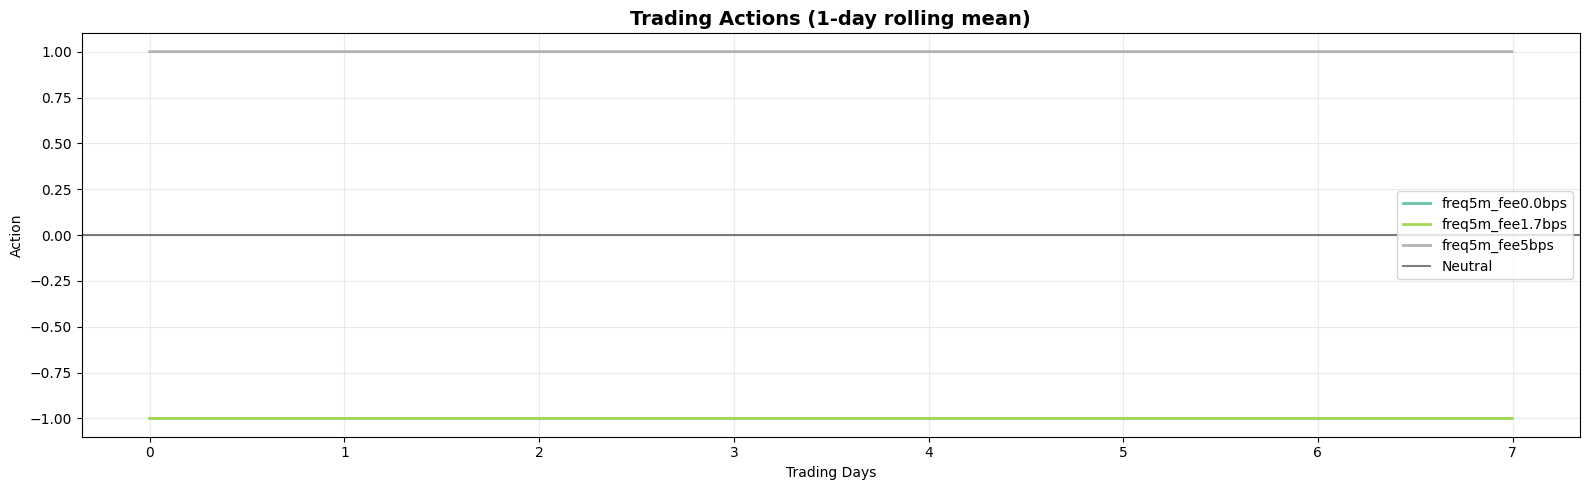


--- 30m ---


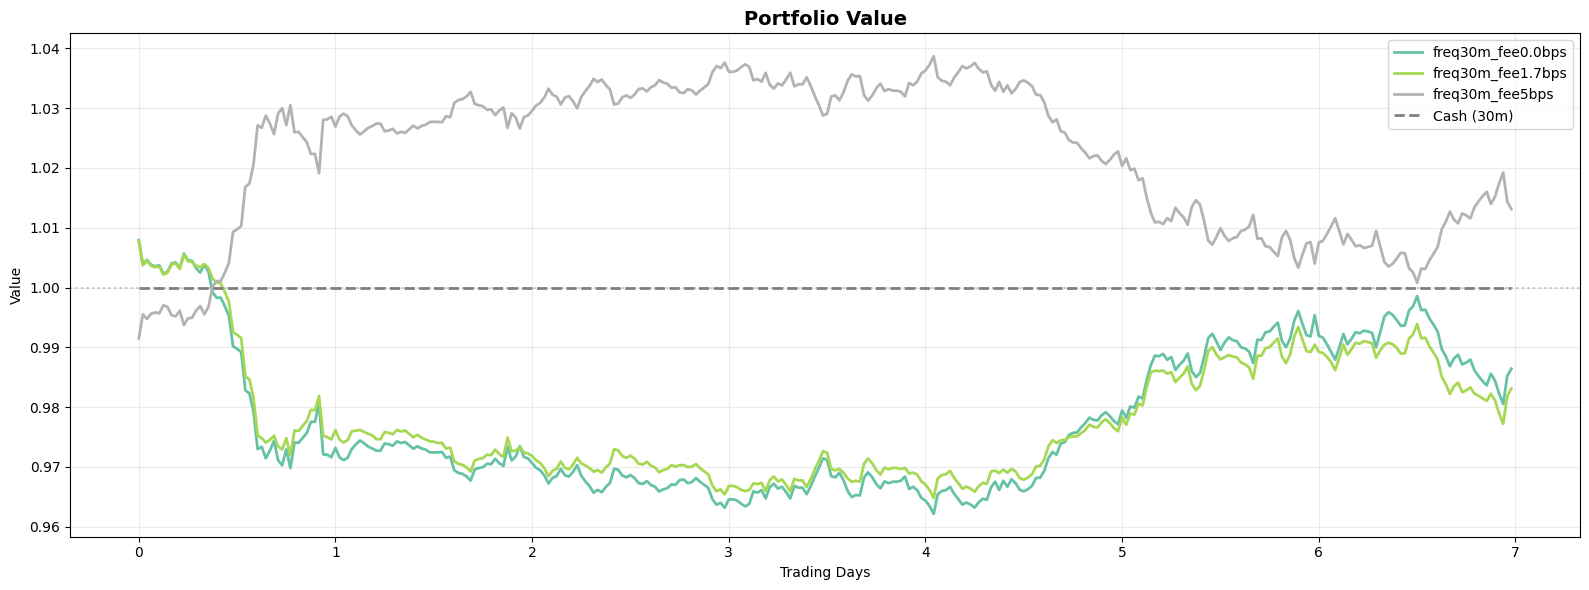

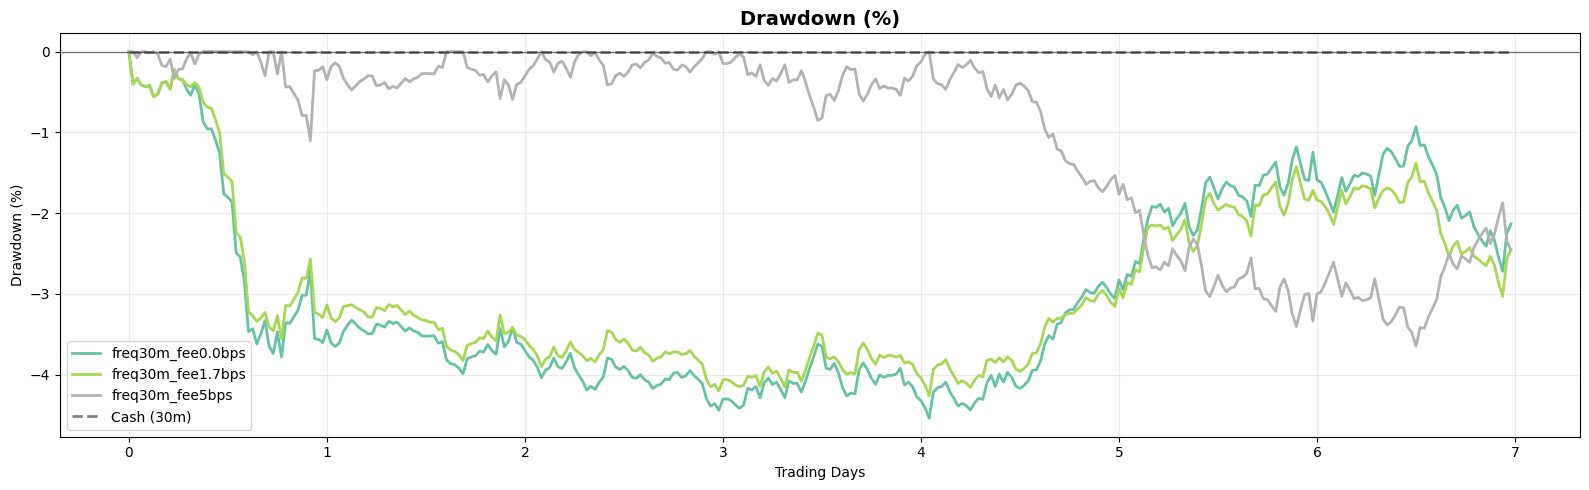

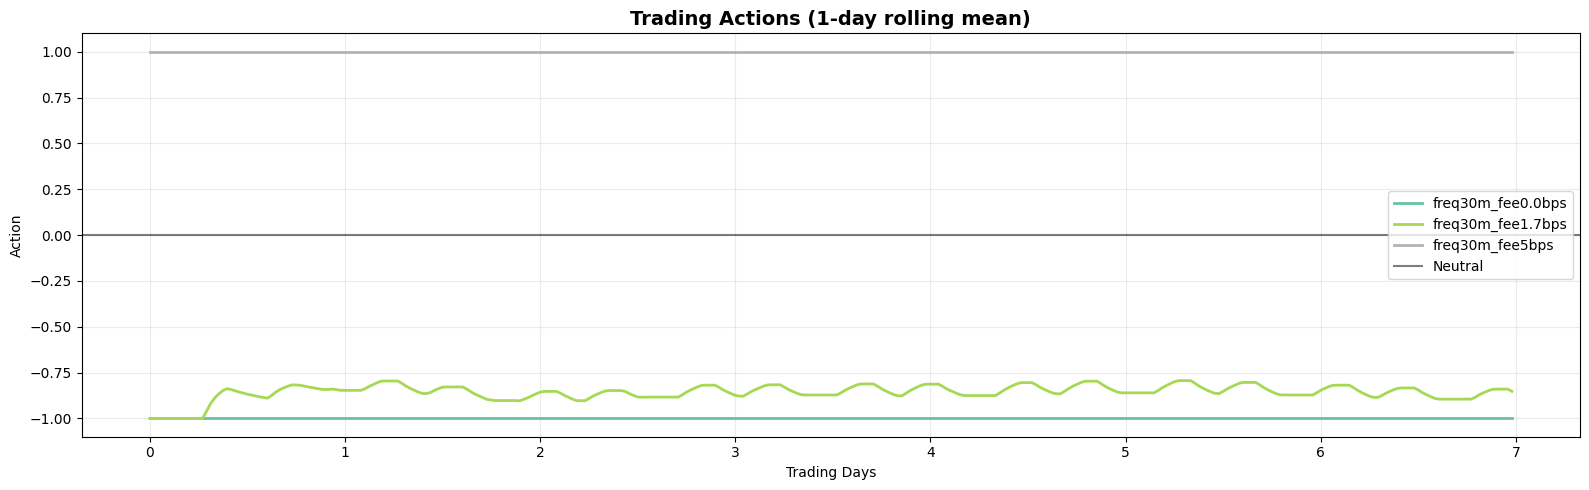

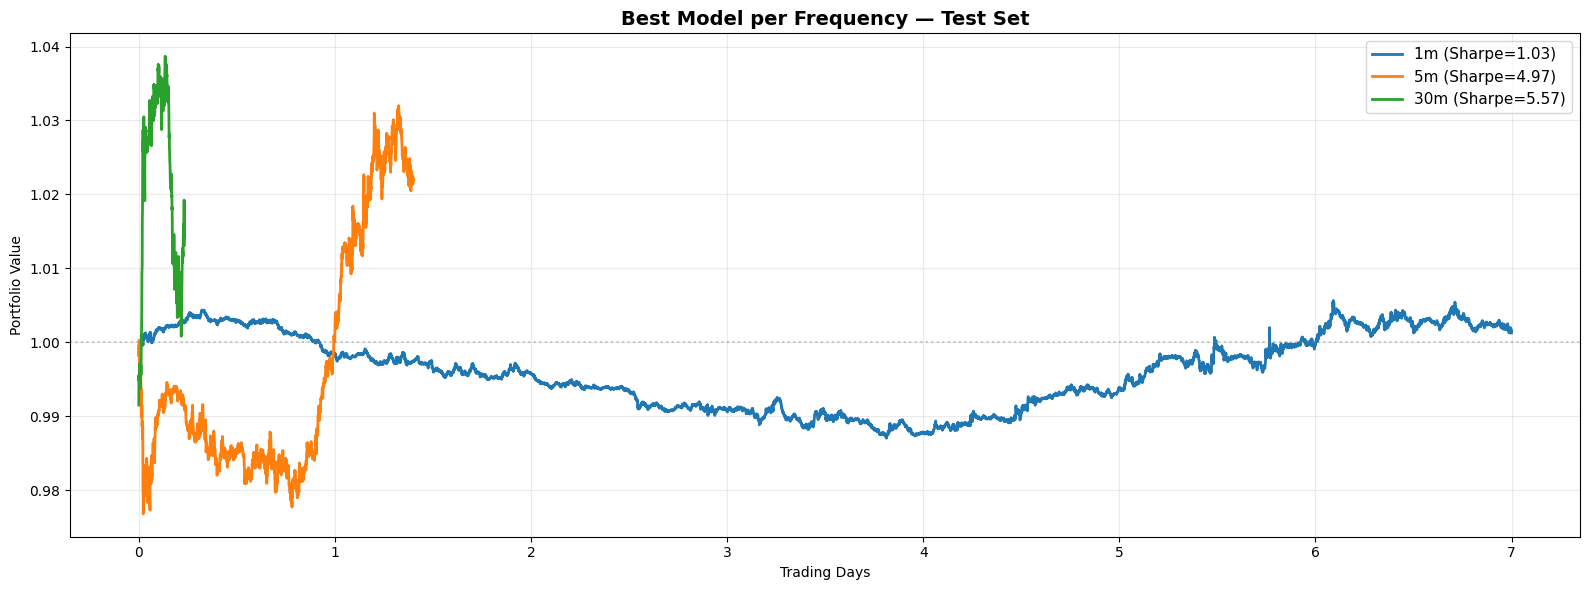

In [19]:
reports_dir = CONFIG["EVAL"]["reports_dir"]
os.makedirs(reports_dir, exist_ok=True)

# --- Per-frequency comparison ---
for freq in FREQUENCIES:
    freq_results = [r for r in all_eval_results if r["frequency"] == freq]
    if not freq_results:
        continue

    # Assign colors
    colors = plt.cm.Set2(np.linspace(0, 1, len(freq_results)))
    for i, r in enumerate(freq_results):
        r["color"] = colors[i]
        r["linestyle"] = "-"

    bl = baseline_results.get(freq)
    bl_formatted = {
        "model_name": bl["model_name"],
        "equity_curve": bl["equity_curve"],
    } if bl else None

    print(f"\n--- {freq} ---")
    plot_comparison(
        freq_results,
        baseline_result=bl_formatted,
        sampling=freq,
        save_dir=reports_dir,
    )

# --- Cross-frequency best models ---
if len(FREQUENCIES) > 1:
    best_per_freq = {}
    for freq in FREQUENCIES:
        freq_results = [r for r in all_eval_results if r["frequency"] == freq]
        if freq_results:
            best = max(freq_results, key=lambda r: r["Sharpe"])
            best_per_freq[freq] = best

    curves = {f"{freq} (Sharpe={r['Sharpe']:.2f})": r["equity_curve"]
              for freq, r in best_per_freq.items()}
    plot_equity_curves(
        curves,
        title="Best Model per Frequency — Test Set",
        sampling=FREQUENCIES[0],
        save_path=os.path.join(reports_dir, "cross_freq_best.pdf"),
    )

## 16 · Save Results

In [20]:
ts = datetime.now().strftime("%Y%m%d_%H%M%S")
csv_path = os.path.join(reports_dir, f"results_{ts}.csv")
df_comparison.to_csv(csv_path, index=False)

# JSON (exclude non-serializable equity curves)
json_rows = []
for r in all_eval_results:
    jr = {k: v for k, v in r.items() if k not in ("equity_curve", "actions")}
    jr = {k: (float(v) if isinstance(v, (np.floating, float)) else v) for k, v in jr.items()}
    json_rows.append(jr)

json_path = os.path.join(reports_dir, f"results_{ts}.json")
with open(json_path, "w") as f:
    json.dump(json_rows, f, indent=2, default=str)

print(f"Saved: {csv_path}")
print(f"Saved: {json_path}")

Saved: ./reports/results_20260415_153003.csv
Saved: ./reports/results_20260415_153003.json
